In [ ]:
 #Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

%matplotlib inline


In [ ]:
#Load the Titanic Dataset
data = sns.load_dataset('titanic')
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
#Explore the Dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [6]:
data.describe(include='all')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
data['age'].fillna(data['age'].median(), inplace=True)
data['embarked'].fillna(data['embarked'].mode()[0], inplace=True)
data.drop(columns=['deck'], inplace=True)
data.head()
data.isnull().sum()

C:\Users\CBS\AppData\Local\Temp\ipykernel_9060\451044691.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['age'].fillna(data['age'].median(), inplace=True)
C:\Users\CBS\AppData\Local\Temp\ipykernel_9060\451044691.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64

In [8]:
data = data.drop(columns=['embark_town'])
data.isnull().sum()

survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alive         0
alone         0
dtype: int64

In [9]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,no,True


In [ ]:
#Handle Missing Values
data.drop(columns=['class','alive','who'], inplace=True)
data.isnull().sum()

survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
adult_male    0
alone         0
dtype: int64

In [11]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male,alone
0,0,3,male,22.0,1,0,7.2500,S,True,False
1,1,1,female,38.0,1,0,71.2833,C,False,False
2,1,3,female,26.0,0,0,7.9250,S,False,True
3,1,1,female,35.0,1,0,53.1000,S,False,False
4,0,3,male,35.0,0,0,8.0500,S,True,True


In [12]:
data.shape

(891, 10)

In [ ]:
 #Encode Categorical Variables
data['sex'] = data['sex'].map({'male': 0, 'female': 1})
data['adult_male'] = data['adult_male'].astype(int)
data['alone'] = data['alone'].astype(int)

data = pd.get_dummies(data, columns=['embarked'], drop_first=True)
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,adult_male,alone,embarked_Q,embarked_S
0,0,3,0,22.0,1,0,7.2500,1,0,False,True
1,1,1,1,38.0,1,0,71.2833,0,0,False,False
2,1,3,1,26.0,0,0,7.9250,0,1,False,True
3,1,1,1,35.0,1,0,53.1000,0,0,False,True
4,0,3,0,35.0,0,0,8.0500,1,1,False,True


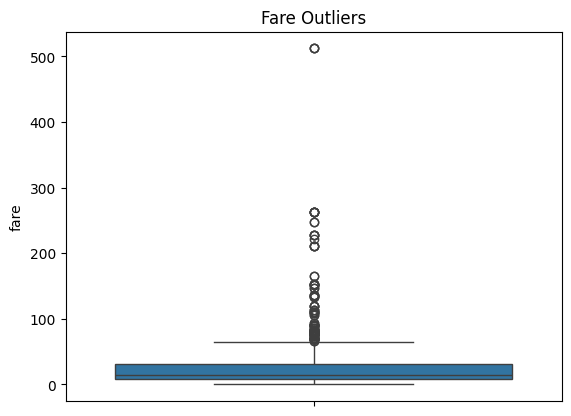

In [14]:
sns.boxplot(data['fare'])
plt.title('Fare Outliers')
plt.show()

In [ ]:
# Removing outliers 

Q1 = data['fare'].quantile(0.25)
Q3 = data['fare'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data = data[(data['fare'] >= lower) & (data['fare'] <= upper)]
print(lower)
print(upper)
data.head()
data.shape

-19.021437499999998
52.7578625


(745, 11)

In [18]:
#feature scaling

scaler = StandardScaler()
data[['age','fare']] = scaler.fit_transform(data[['age','fare']])
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,adult_male,alone,embarked_Q,embarked_S
0,0,3,0,-0.512562,1,0,-0.800865,1,0,False,True
2,1,3,1,-0.199258,0,0,-0.740679,0,1,False,True
4,0,3,0,0.505676,0,0,-0.729534,1,1,False,True
5,0,3,0,-0.042606,0,0,-0.693128,1,1,True,False
6,0,1,0,1.993869,0,0,3.176957,1,1,False,True


In [25]:
# Feature Engineering

data['family_size'] = data['sibsp'] + data['parch'] + 1
data['is_alone'] = np.where(data['family_size']==1,1,0)
data[['family_size','is_alone']].head()
data.head()


,survived,pclass,sex,age,sibsp,parch,fare,adult_male,alone,embarked_Q,embarked_S,family_size,is_alone
0,0,3,0,-0.512562,1,0,-0.800865,1,0,False,True,2,0
2,1,3,1,-0.199258,0,0,-0.740679,0,1,False,True,1,1
4,0,3,0,0.505676,0,0,-0.729534,1,1,False,True,1,1
5,0,3,0,-0.042606,0,0,-0.693128,1,1,True,False,1,1
6,0,1,0,1.993869,0,0,3.176957,1,1,False,True,1,1


In [26]:
data.shape

(745, 13)

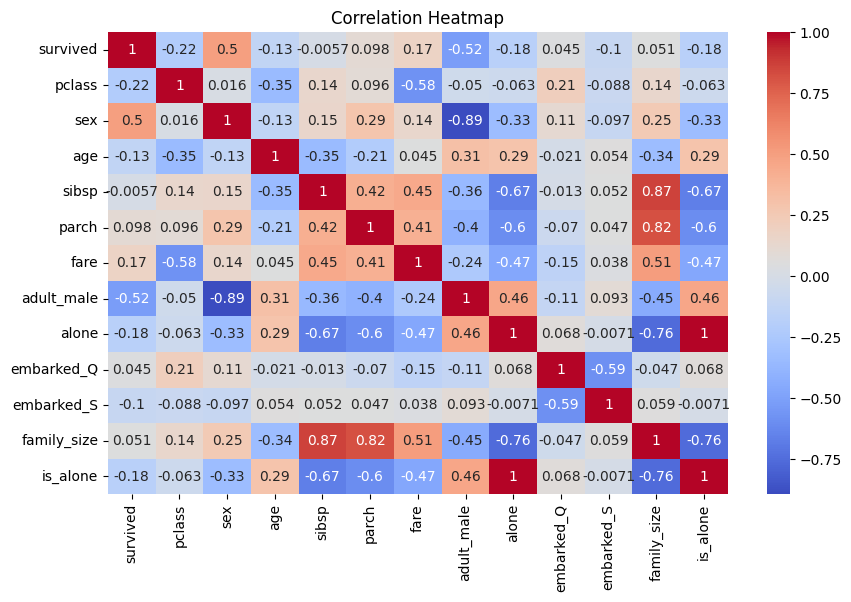

In [27]:
#Correlation Heatmap

plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [30]:
data.drop(columns=['is_alone'], inplace=True)

In [31]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,adult_male,alone,embarked_Q,embarked_S,family_size
0,0,3,0,-0.512562,1,0,-0.800865,1,0,False,True,2
2,1,3,1,-0.199258,0,0,-0.740679,0,1,False,True,1
4,0,3,0,0.505676,0,0,-0.729534,1,1,False,True,1
5,0,3,0,-0.042606,0,0,-0.693128,1,1,True,False,1
6,0,1,0,1.993869,0,0,3.176957,1,1,False,True,1


In [32]:
#Split Data into Features and Target
X = data.drop('survived', axis=1)
y = data['survived']

In [33]:
#Train–Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape


((596, 11), (149, 11))

In [34]:
#Train Logistic Regression Model
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [37]:
 #Predictions
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
y_pred[:10]


Accuracy: 0.8187919463087249


array([1, 1, 0, 0, 1, 1, 1, 0, 0, 0])

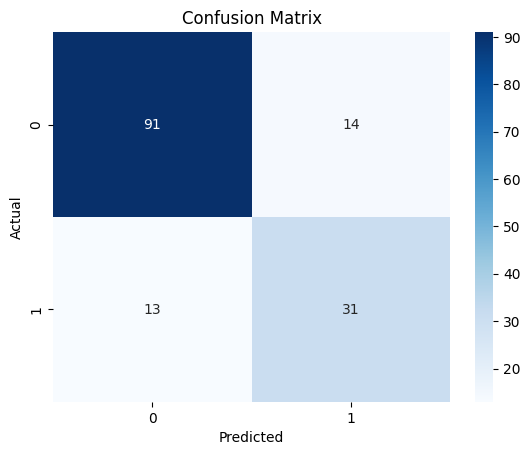

In [38]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()